In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
caminho_inputs = "dataset/ovarianInputs.xlsx"
caminho_targets = "dataset/ovarianTargets.xls"

df_inputs = pd.read_excel(caminho_inputs, header=None)
df_targets = pd.read_excel(caminho_targets, header=None)

seed = 42

In [3]:
X = df_inputs.values

In [4]:
y = df_targets[0].values

print(f"Formato original de X: {X.shape}")
print(f"Formato original do target: {df_targets.shape}")
print(f"Formato tratado de y (1D): {y.shape}\n")

print(f"Total de amostras: {len(y)}")
print(f"Pacientes com Câncer (Classe 1): {np.sum(y == 1)}")
print(f"Pacientes Normais (Classe 0): {np.sum(y == 0)}\n")

Formato original de X: (216, 100)
Formato original do target: (216, 2)
Formato tratado de y (1D): (216,)

Total de amostras: 216
Pacientes com Câncer (Classe 1): 121
Pacientes Normais (Classe 0): 95



In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=seed, stratify=y
)

print(f"Tamanho do Treino: {X_train.shape[0]} amostras")
print(f"Tamanho do Teste: {X_test.shape[0]} amostras")

Tamanho do Treino: 172 amostras
Tamanho do Teste: 44 amostras


In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
pca = PCA(n_components=50, random_state=seed)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Dimensões do Treino após o PCA: {X_train_pca.shape}")
print(f"Dimensões do Teste após o PCA: {X_test_pca.shape}")

variancia_explicada = np.sum(pca.explained_variance_ratio_) * 100
print(
    f"As 50 componentes explicam {variancia_explicada:.2f}% da variância original dos dados."
)

Dimensões do Treino após o PCA: (172, 50)
Dimensões do Teste após o PCA: (44, 50)
As 50 componentes explicam 99.88% da variância original dos dados.


In [8]:
modelo = LogisticRegression(random_state=seed, max_iter=1000)
modelo.fit(X_train_pca, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [9]:
y_pred = modelo.predict(X_test_pca)

In [10]:
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

In [11]:
acuracia = accuracy_score(y_test, y_pred)
sensibilidade = TP / (TP + FN)
especificidade = TN / (TN + FP)

print(f"Acurácia: {acuracia * 100:.2f}%")
print(f"Sensibilidade: {sensibilidade * 100:.2f}%")
print(f"Especificidade: {especificidade * 100:.2f}%\n")

Acurácia: 100.00%
Sensibilidade: 100.00%
Especificidade: 100.00%



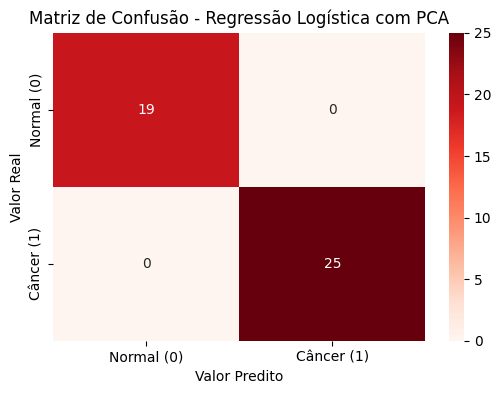

              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00        19
  Câncer (1)       1.00      1.00      1.00        25

    accuracy                           1.00        44
   macro avg       1.00      1.00      1.00        44
weighted avg       1.00      1.00      1.00        44



In [12]:
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=["Normal (0)", "Câncer (1)"],
    yticklabels=["Normal (0)", "Câncer (1)"],
)
plt.title("Matriz de Confusão - Regressão Logística com PCA")
plt.ylabel("Valor Real")
plt.xlabel("Valor Predito")
plt.show()

print(classification_report(y_test, y_pred, target_names=["Normal (0)", "Câncer (1)"]))

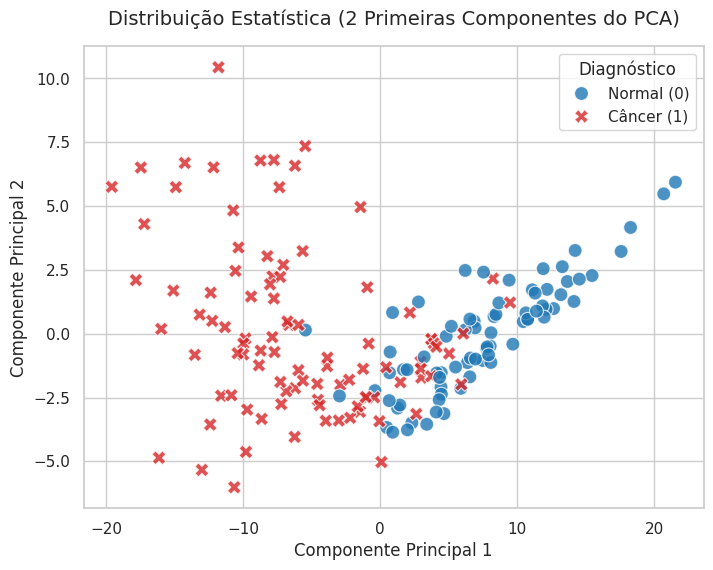

In [14]:
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

X_pca_2d = pca.transform(X_train_scaled)[:, :2]

sns.scatterplot(
    x=X_pca_2d[:, 0],
    y=X_pca_2d[:, 1],
    hue=y_train,
    palette=["#1f77b4", "#d62728"],
    style=y_train,
    s=100,
    alpha=0.8,
)

plt.title(
    "Distribuição Estatística (2 Primeiras Componentes do PCA)", fontsize=14, pad=15
)
plt.xlabel("Componente Principal 1", fontsize=12)
plt.ylabel("Componente Principal 2", fontsize=12)

handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles, ["Normal (0)", "Câncer (1)"], title="Diagnóstico")
plt.show()